In [107]:
!pip install hvplot

In [108]:
import numpy as np
import pandas as pd
import hvplot.pandas
import seaborn as sns
import holoviews as hv

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [109]:
dailyCustomers = pd.read_csv('https://tinyurl.com/ChrisCoDV/001408475/StoreDailyCustomers.csv',index_col=0)
storeMarketing = pd.read_csv('https://tinyurl.com/ChrisCoDV/001408475/StoreMarketing.csv',index_col=0)
storeOverheads = pd.read_csv('https://tinyurl.com/ChrisCoDV/001408475/StoreOverheads.csv',index_col=0)
storeSize = pd.read_csv('https://tinyurl.com/ChrisCoDV/001408475/StoreSize.csv',index_col=0)
storeStaff = pd.read_csv('https://tinyurl.com/ChrisCoDV/001408475/StoreStaff.csv',index_col=0)

In [110]:
dailyCustomers.index = pd.to_datetime(dailyCustomers.index)

##Daily Customers Dataframe##

In [111]:
dailyCustomers.head(10)

,TVW,QUF,GIN,WHI,ICK,TBH,WPT,RIK,HWR,UPM,...,UVL,IIU,AQZ,FOX,VCF,WWU,RVP,HOF,VPA,RBZ
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-01,489,0,54,909,86,353,1112,0,104,590,...,64,71,0,91,69,54,462,55,61,0
2023-01-02,519,0,33,922,95,377,1054,0,83,629,...,77,90,0,71,72,73,372,65,85,0
2023-01-03,357,0,61,915,83,298,960,0,80,591,...,76,75,0,67,71,55,411,52,90,0
2023-01-04,496,0,47,860,84,322,910,0,95,471,...,79,71,0,84,76,52,327,56,84,0
2023-01-05,301,0,54,645,88,300,911,0,96,448,...,74,86,0,98,50,85,323,59,66,0
2023-01-06,369,0,58,747,89,355,994,0,111,637,...,79,72,0,95,66,49,383,57,55,0
2023-01-07,473,0,50,891,88,397,1024,0,90,550,...,76,66,0,79,82,56,431,63,76,0
2023-01-08,507,0,62,799,88,400,1122,0,88,412,...,73,82,0,95,79,50,423,66,91,0
2023-01-09,378,0,36,834,88,349,1075,0,125,466,...,80,75,0,85,78,69,418,58,75,0


In [112]:
dailyCustomers = dailyCustomers.reindex(dailyCustomers.sum(axis=0).sort_values(ascending=False).index, axis=1)

print(dailyCustomers.sum(axis=0).head(15))
print(dailyCustomers.sum(axis=0).tail(5))

WPT    360102
WBY    340779
VVE    332117
WHI    318767
UPM    179152
TVW    172209
VBO    169775
UJB    150771
RVP    141815
SPC    140347
TBH    131711
SJR    120659
HWR     33414
XCM     33302
YQR     32363
dtype: int64
BCD    10765
QUF     9107
AQZ     8852
QOU     5898
RIK     4113
dtype: int64


###Time Series Analysis for dailyCustomers Dataframe###

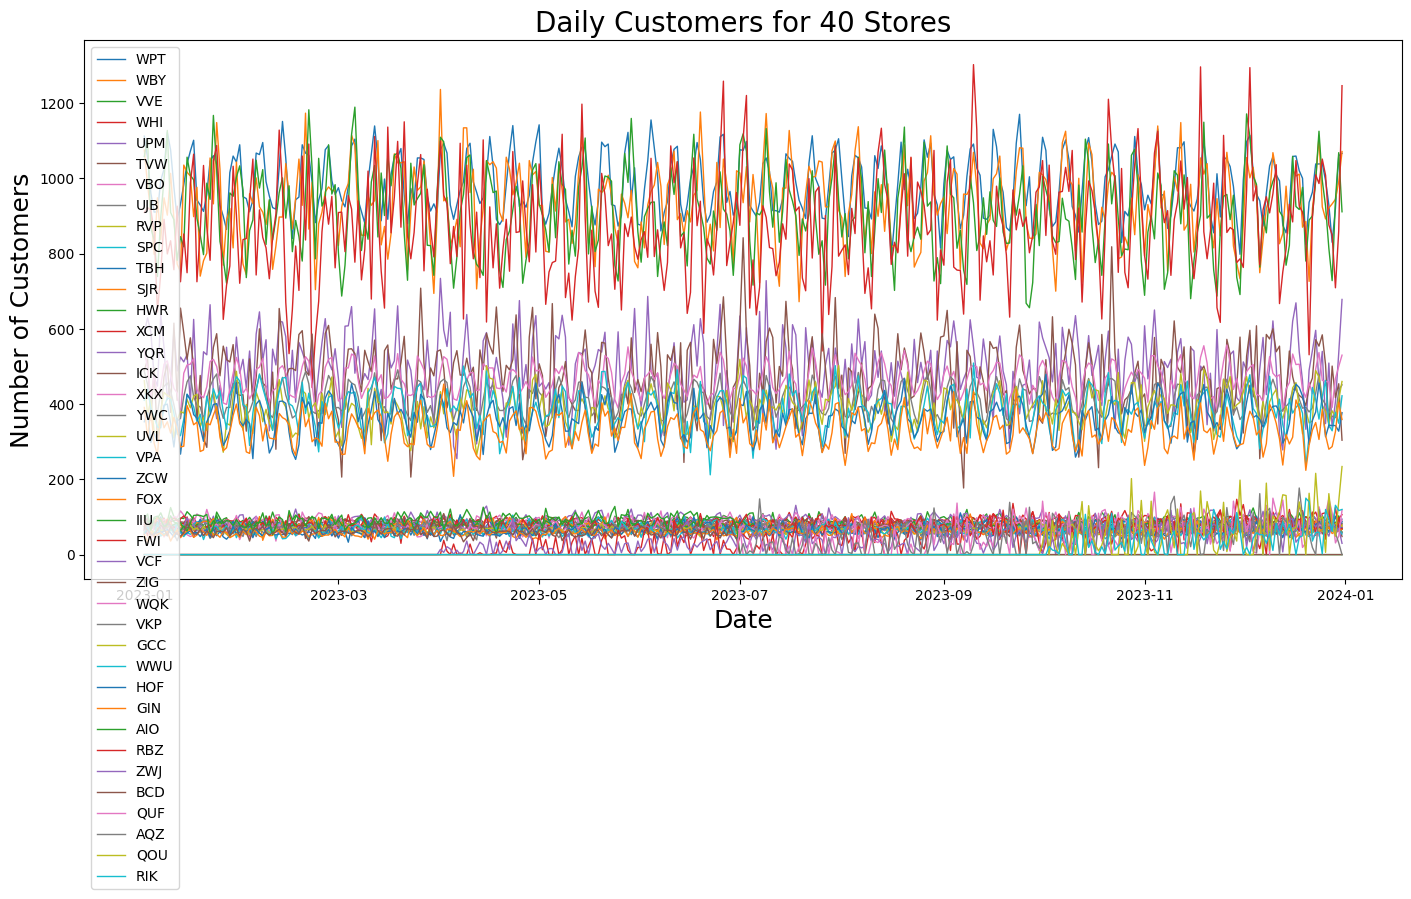

In [113]:
plt.figure(figsize=(17, 7))
plt.plot(dailyCustomers, linewidth=1)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Number of Customers', fontsize=18)
plt.title('Daily Customers for 40 Stores', fontsize=20)
plt.legend(dailyCustomers.columns, loc=2)
plt.show()

###Segmentation of Al Stores by Volume###

High: ['WPT', 'WBY', 'VVE', 'WHI']
Medium: ['UPM', 'TVW', 'VBO', 'UJB', 'RVP', 'SPC', 'TBH', 'SJR']
Low: ['HWR', 'XCM', 'YQR', 'ICK', 'XKX', 'YWC', 'UVL', 'VPA', 'ZCW', 'FOX', 'IIU', 'FWI', 'VCF', 'ZIG', 'WQK', 'VKP', 'GCC', 'WWU', 'HOF', 'GIN', 'AIO', 'RBZ', 'ZWJ', 'BCD', 'QUF', 'AQZ', 'QOU', 'RIK']


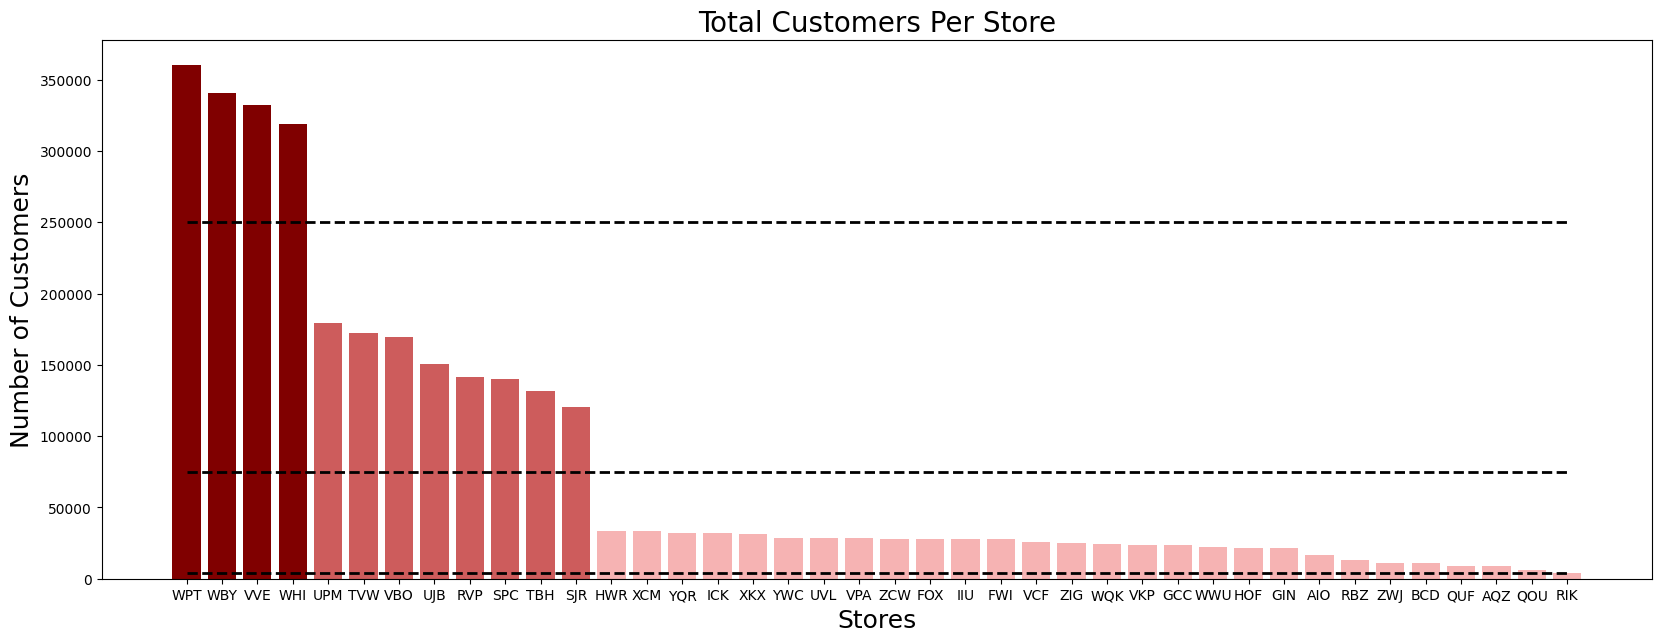

In [114]:
segment_limits = {  # lower limits for each segment (must be in ascending order!)
    4000: 'Low',
    75_000: 'Medium',
    250_000: 'High',
}
limits = list(segment_limits.keys())
segments = {}
for i in range(len(limits)):
    if i < len(limits) - 1:
        included = (limits[i] <= dailyCustomers.sum()) & (dailyCustomers.sum() < limits[i + 1])  # the round brackets are important
    else:
        included = (limits[i] <= dailyCustomers.sum())  # the round brackets are important
    segment_name = segment_limits[limits[i]]
    segment_columns = dailyCustomers.columns[included]
    segments[segment_name] = list(segment_columns)

for segment_name in reversed(segments):
    print(f'{segment_name}: {segments[segment_name]}')

segment_colours = {  # segment names must match those in segment_limits
    'Low': '#f6b3b3',
    'Medium': 'indianred',
    'High': 'maroon',
}
colours = []
for name in dailyCustomers.columns:
    for segment_name in segments:
        if name in segments[segment_name]:
            colour = segment_colours[segment_name]
            colours.append(colour)
            break


plt.figure(figsize=(20, 7))
x = np.arange(len(dailyCustomers.columns))
plt.bar(x, dailyCustomers.sum(), align='center', color=colours)
plt.xticks(x, dailyCustomers.columns)
plt.xlabel('Stores', fontsize=18)
plt.ylabel('Number of Customers', fontsize=18)
plt.title('Total Customers Per Store', fontsize=20)

plt.plot([0, 39], [250_000, 250_000], linestyle='--', linewidth=2, color='black')
plt.plot([0, 39], [75_000, 75_000], linestyle='--', linewidth=2, color='black')
plt.plot([0, 39], [4000, 4000], linestyle='--', linewidth=2, color='black')

plt.show()

###14-day Rolling average for High and Medium Volume Stores###


             WPT   WBY   VVE  WHI  UPM  TVW  VBO  UJB  RVP  SPC  TBH  SJR
Date                                                                     
2023-01-01  1112  1075  1058  909  590  489  544  487  462  410  353  391
2023-01-02  1054   982  1104  922  629  519  495  452  372  440  377  312
2023-01-03   960   911   867  915  591  357  416  390  411  389  298  381
2023-01-04   910   798   837  860  471  496  479  360  327  365  322  296
2023-01-05   911   948   739  645  448  301  418  376  323  339  300  265


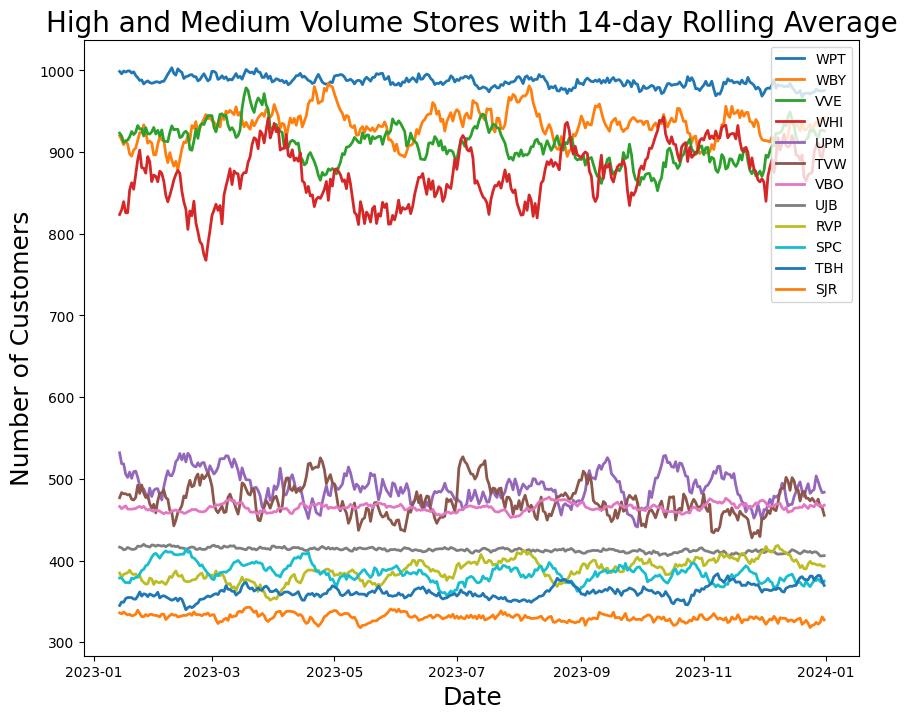

In [115]:
selected = ['WPT','WBY','VVE','WHI','UPM','TVW','VBO','UJB','RVP','SPC','TBH','SJR']

period = 14
rolling_average = dailyCustomers.rolling(window=period).mean()

print(dailyCustomers[selected].head())

plt.figure(figsize=(10, 8))
#plt.plot(dailyCustomers[selected], linewidth=0.5)
plt.gca().set_prop_cycle(None)
plt.plot(rolling_average[selected], linewidth=2)
# plt.ylim(ymin=0)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Number of Customers', fontsize=18)
plt.title('High and Medium Volume Stores with 14-day Rolling Average', fontsize=20)
plt.legend(selected, loc=1)
plt.show()

###14-day Rolling-Average for Low Volume Stores with Interaction###
This is an interactive visualization with different tools to allow a deeper analysis of the plot by interacting with it in multiple ways. These tools are as follows:

* There is a legend containing the list of stores and a colour associated with that store. Clicking on any store name in the legend will  make the line plot of that store become transparent. This will enable to hide all the line plots that we are uninterested in, so that we can focus on the interesting ones.
*   There is a Pan tool which when clicked, allows us to drag the region of the plot along the x and y axes so that we can investigate the region of our interest e.g. we can drag a time-series line plot to an older date on the x-axis to investigate what happened on that date.
*   There is a Box zoom tool which upon clicking, allows zooming into any region of the plot by creating a box around that region with the cursor.
*   There is a Wheel zoom tool which upon clicking allows one to zoom-in to any part of the interactive plot by scrolling down with mouse and alternately allows zooming-out of the plot by scrlling up with mouse.
*   There is a Save button which upon clicking, allows saving and downloading of the current state of the interactive plot as a png image with the name of your choice.
*   There is a Reset button, which upon clicking restores the plot to its original form if it has been formatted with other tools such as zoom and pan.
*   There is a Hover button, for each line plotted, which upon clicking displays text containing statistics such as x and y-values at any point for that line by bringing the cursor to that point on the line.











In [116]:
#selecting the column numbers from 12 to 40 which represent low volume stores
selected = dailyCustomers.columns.values[12:]


period=14
rolling_average = dailyCustomers.rolling(window=period).mean()

plot = rolling_average[selected].hvplot.line(
    frame_height=500, frame_width=1000,
    xlabel='Date', ylabel='Number of Customers',
    title='Low Volume Stores with 14-day Rolling Average'
)
hvplot.extension('bokeh')
plot

:NdOverlay   [Variable]
   :Curve   [Date]   (value)

###Correlation Heatmap for 40 Stores with Interaction###
This is an interactive visualization with different tools to allow a deeper analysis of the plot by interacting with it in multiple ways. These tools are as follows:


*   There is a Pan tool which when clicked, allows us to drag the region of the plot along the x and y axes so that we can investigate the region of our interest e.g. we can drag a time-series line plot to an older date on the x-axis to investigate what happened on that date.
*   There is a Box zoom tool which upon clicking, allows zooming into any region of the plot by creating a box around that region with the cursor.
*   There is a Wheel zoom tool which upon clicking allows one to zoom-in to any part of the interactive plot by scrolling down with mouse and alternately allows zooming-out of the plot by scrlling up with mouse.
*   There is a Save button which upon clicking, allows saving and downloading of the current state of the interactive plot as a png image with the name of your choice.
*   There is a Reset button, which upon clicking restores the plot to its original form if it has been formatted with other tools such as zoom and pan.
*   There is a single Hover button which upon clicking displays text containing statistics such as x and y-values at any point for that plot by bringing the cursor to that point on the plot.

In [117]:
import pandas as pd
import hvplot.pandas

plot = dailyCustomers.corr().hvplot.heatmap(
    frame_height=600, frame_width=600,
    title='Store correlations',
    rot=90, cmap='coolwarm'  # see http://holoviews.org/user_guide/Colormaps.html
).opts(invert_yaxis=True, clim=(-1, 1))
hvplot.extension('bokeh')
plot


:HeatMap   [columns,index]   (value)

###Outlier Detection From High, Medium and Low volume Stores###

<ipython-input-118-357c17933bce>:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(dailyCustomers[selected1], labels=selected1)
<ipython-input-118-357c17933bce>:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(dailyCustomers[selected2], labels=selected2)
<ipython-input-118-357c17933bce>:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(dailyCustomers[selected3], labels=selected3)


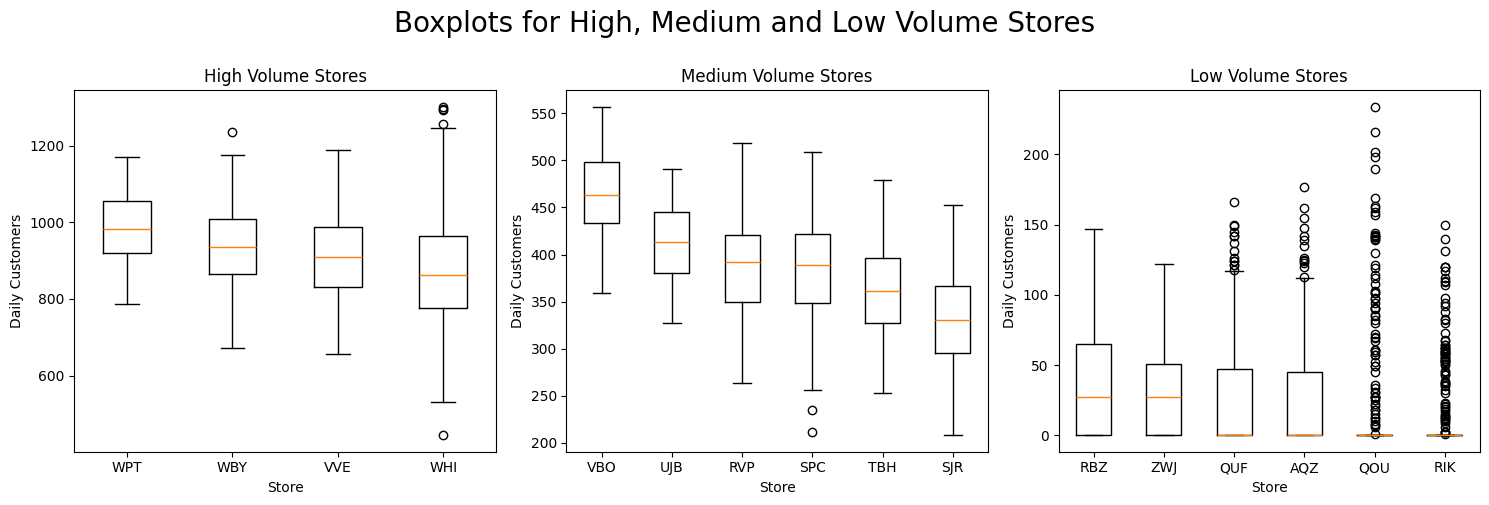

In [118]:
selected1 = ['WPT','WBY','VVE','WHI']
selected2= ['VBO','UJB','RVP','SPC','TBH','SJR']
selected3 = ['RBZ','ZWJ','QUF','AQZ','QOU','RIK']

# Create the subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns
fig.suptitle('Boxplots for High, Medium and Low Volume Stores', fontsize=20, position=(0.5, 1.0))

# Plot boxplot for the first group on the first subplot
axes[0].boxplot(dailyCustomers[selected1], labels=selected1)
axes[0].set_title('High Volume Stores')
axes[0].set_xlabel('Store')
axes[0].set_ylabel('Daily Customers')

# Plot boxplot for the second group on the second subplot
axes[1].boxplot(dailyCustomers[selected2], labels=selected2)
axes[1].set_title('Medium Volume Stores')
axes[1].set_xlabel('Store')
axes[1].set_ylabel('Daily Customers')

# Plot boxplot for the third group on the third subplot
axes[2].boxplot(dailyCustomers[selected3], labels=selected3)
axes[2].set_title('Low Volume Stores')
axes[2].set_xlabel('Store')
axes[2].set_ylabel('Daily Customers')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


###Correlation Scatter Subplots for High and Medium Volume Stores###

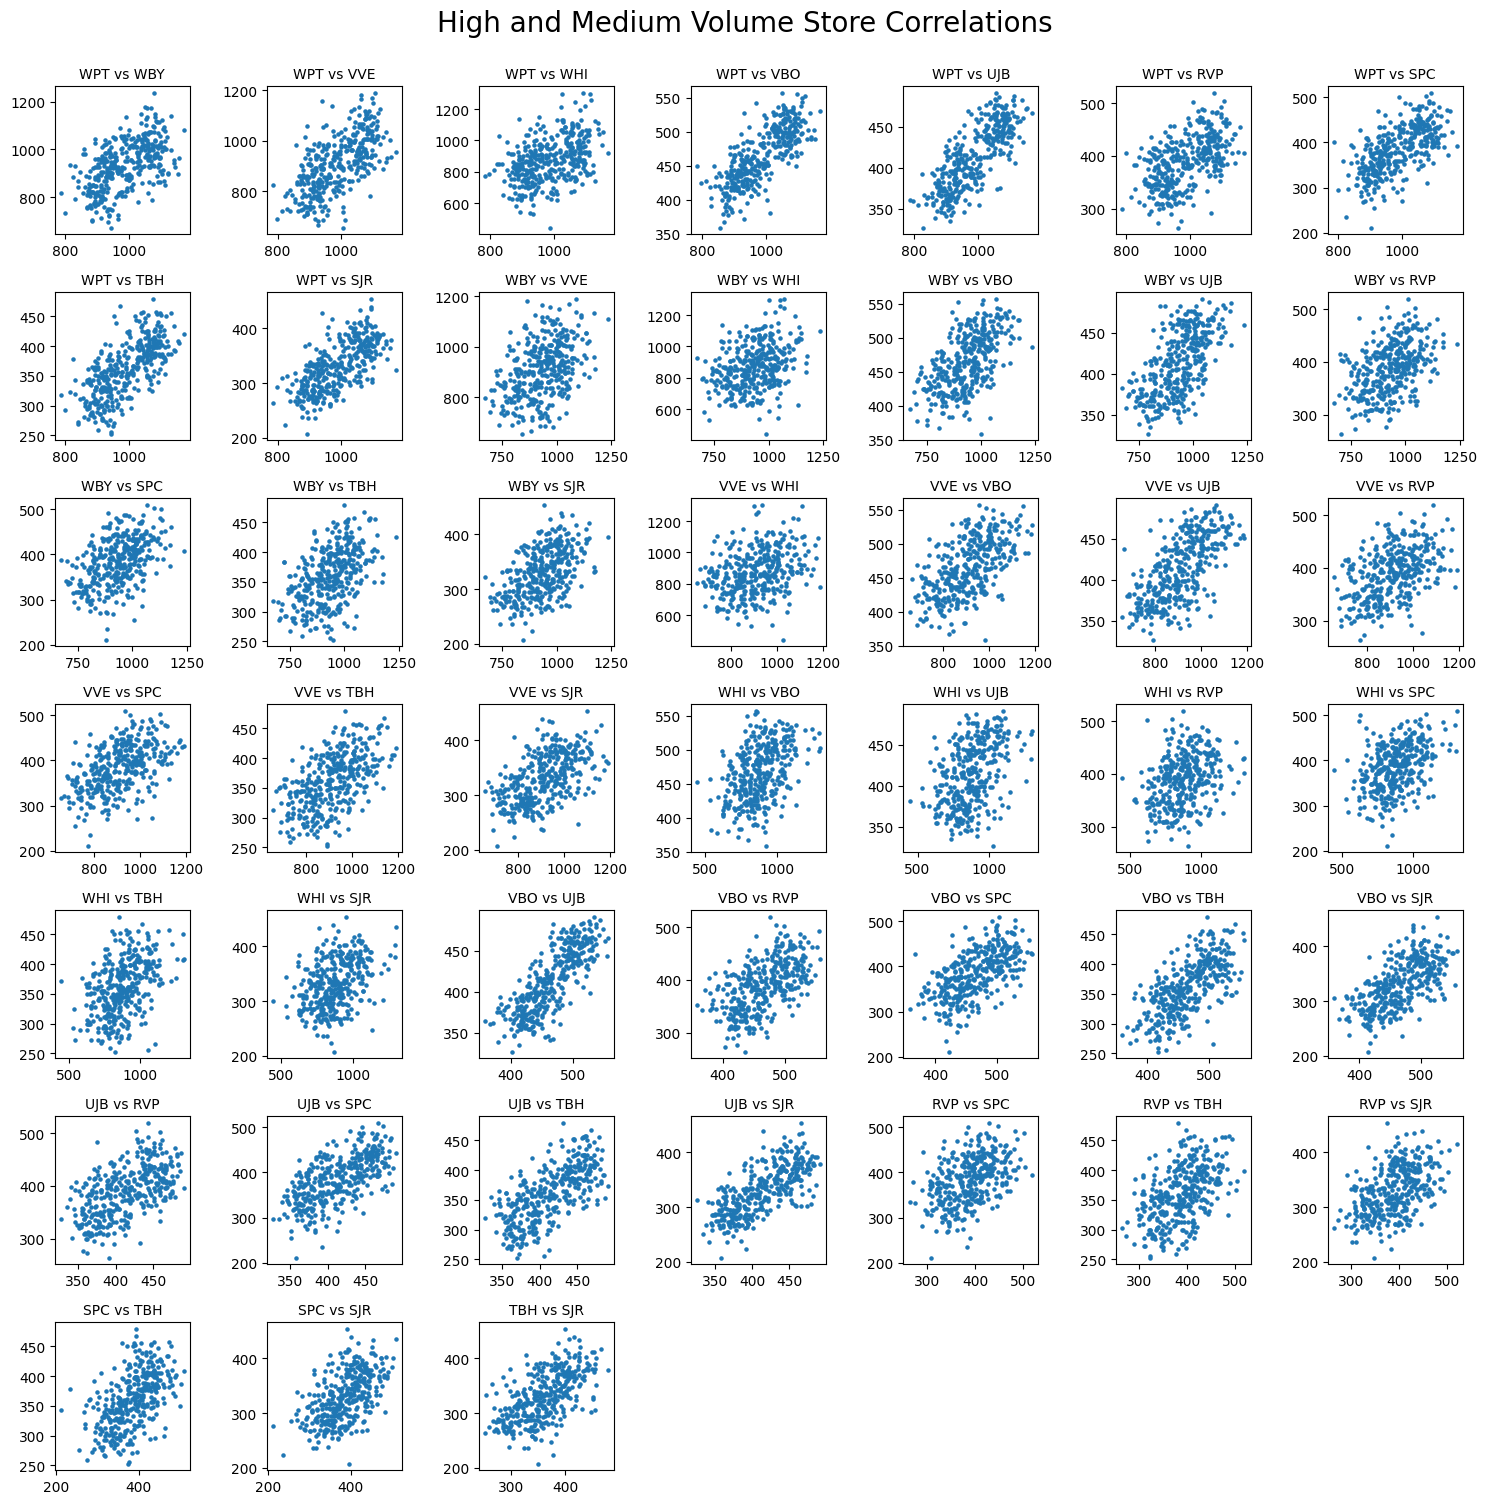

In [119]:
selected = ['WPT','WBY','VVE','WHI','VBO','UJB','RVP','SPC','TBH','SJR']

counter = 1
fig = plt.figure(figsize=(15, 15))
fig.suptitle('High and Medium Volume Store Correlations', fontsize=20, position=(0.5, 1.0))
for i, name_i in enumerate(selected):
    for j in range(i + 1, len(selected)):
        name_j = selected[j]
        sub = fig.add_subplot(7, 7, counter)
        sub.set_title(name_i + ' vs ' + name_j, fontsize=10)
        sub.scatter(dailyCustomers[name_i], dailyCustomers[name_j], s=5)
        counter += 1
plt.subplots_adjust(wspace=20, hspace=5)
plt.tight_layout()
plt.show()

###Correlation Scatter Subplots for Low Volume Stores###

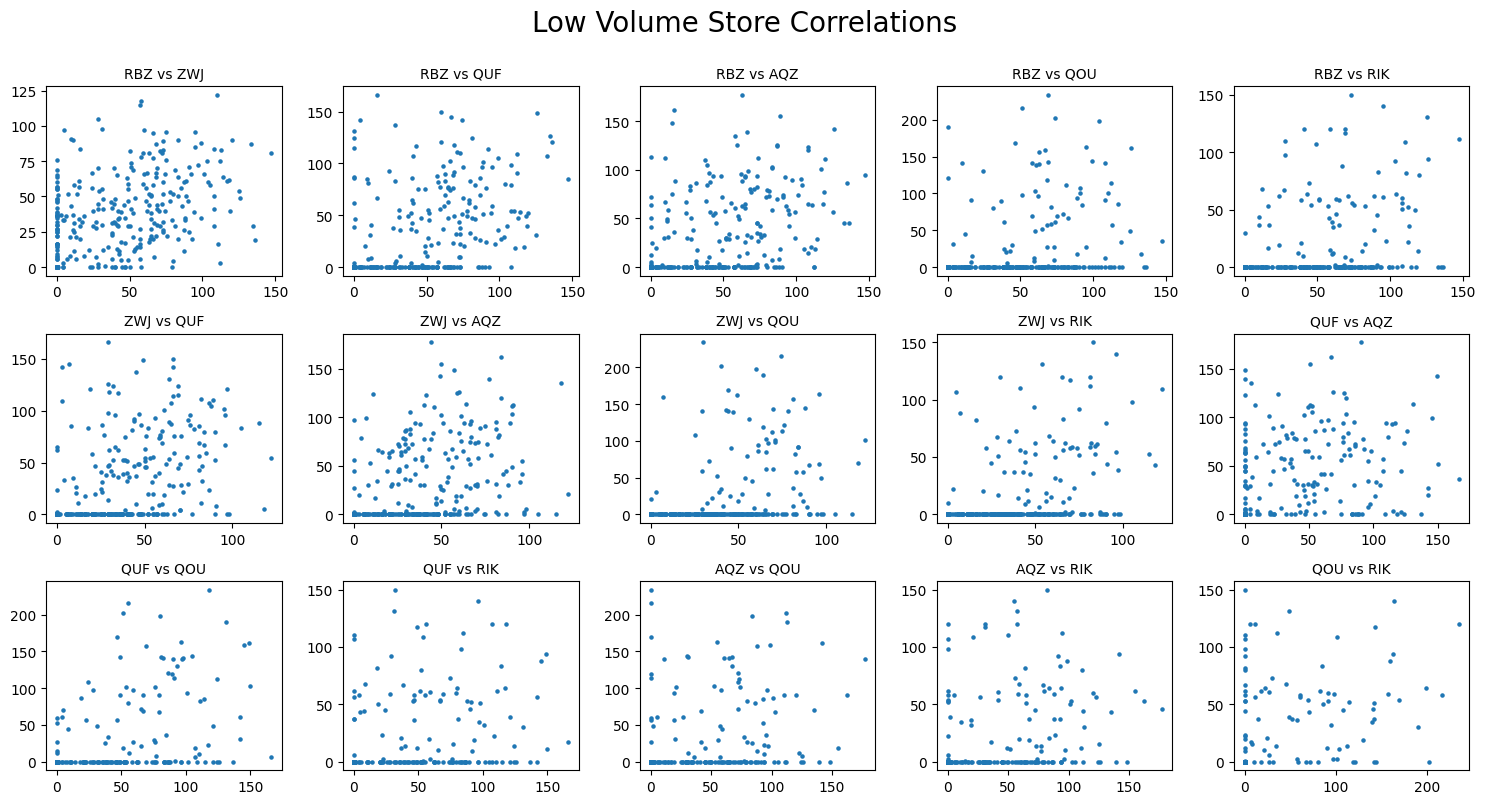

In [120]:
selected = ['RBZ','ZWJ','QUF','AQZ','QOU','RIK']

counter = 1
fig = plt.figure(figsize=(15, 8))
fig.suptitle('Low Volume Store Correlations', fontsize=20, position=(0.5, 1.0))
for i, name_i in enumerate(selected):
    for j in range(i + 1, len(selected)):
        name_j = selected[j]
        sub = fig.add_subplot(3, 5, counter)
        sub.set_title(name_i + ' vs ' + name_j, fontsize=10)
        sub.scatter(dailyCustomers[name_i], dailyCustomers[name_j], s=5)
        counter += 1
plt.subplots_adjust(wspace=20, hspace=5)
plt.tight_layout()
plt.show()

###Autocorrelation for High and Medium Volume Stores###

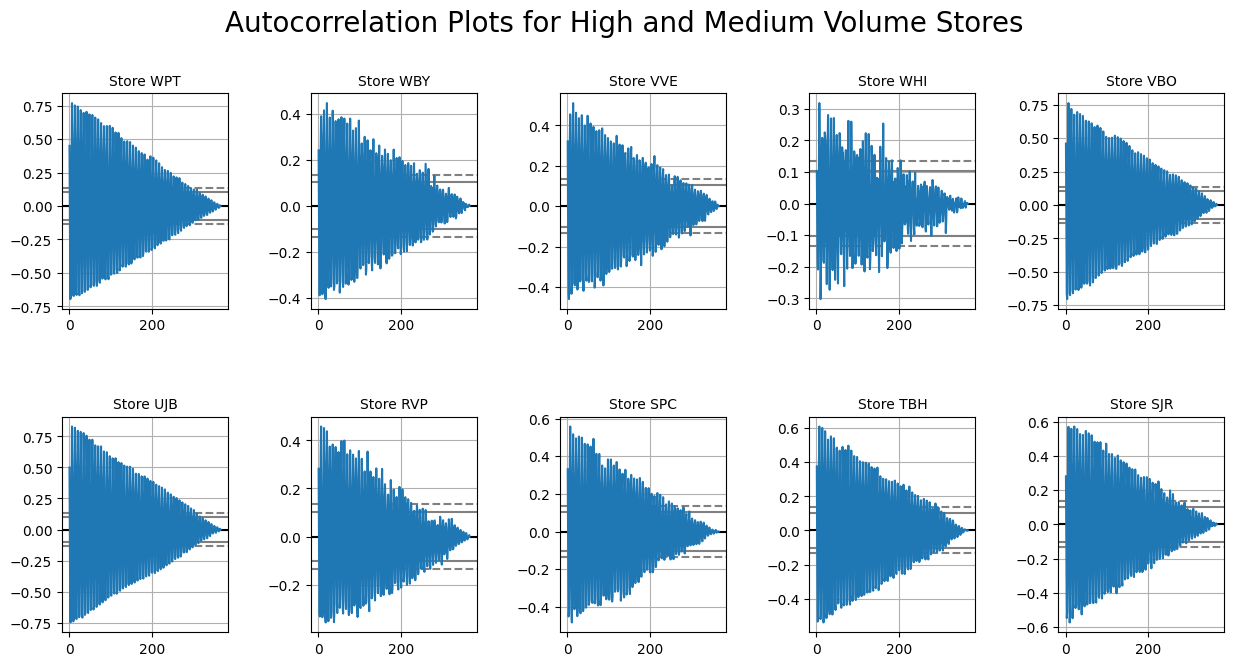

In [121]:
selected = ['WPT','WBY','VVE','WHI','VBO','UJB','RVP','SPC','TBH','SJR']

row = 0
col = 0
fig, axes = plt.subplots(figsize=(15, 7), nrows=2, ncols=5)
fig.suptitle('Autocorrelation Plots for High and Medium Volume Stores', fontsize=20, position=(0.5, 1.0))
for name in selected:
    sub = pd.plotting.autocorrelation_plot(dailyCustomers[name], axes[row, col])
    sub.set_title('Store ' + name, fontsize=10)
    sub.xaxis.label.set_visible(False)
    sub.yaxis.label.set_visible(False)
    col += 1
    if col == 5:
        row += 1
        col = 0
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()


###Autocorrelation for Low Volume Stores###

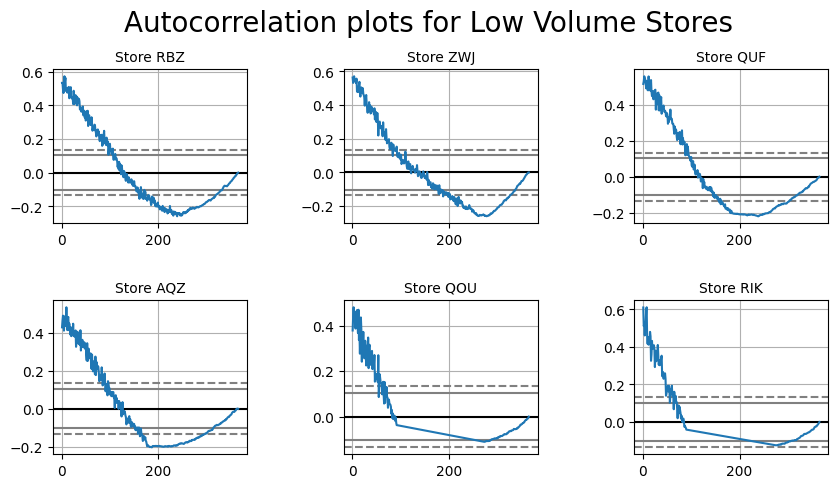

In [122]:
selected = ['RBZ','ZWJ','QUF','AQZ','QOU','RIK']

row = 0
col = 0
fig, axes = plt.subplots(figsize=(10,5), nrows=2, ncols=3)
fig.suptitle('Autocorrelation plots for Low Volume Stores', fontsize=20, position=(0.5, 1.0))
for name in selected:
    sub = pd.plotting.autocorrelation_plot(dailyCustomers[name], axes[row, col])
    sub.set_title('Store ' + name, fontsize=10)
    sub.xaxis.label.set_visible(False)
    sub.yaxis.label.set_visible(False)
    col += 1
    if col == 3:
        row += 1
        col = 0
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

###Seasonality Check for Correlated High and Medium Volume Stores###

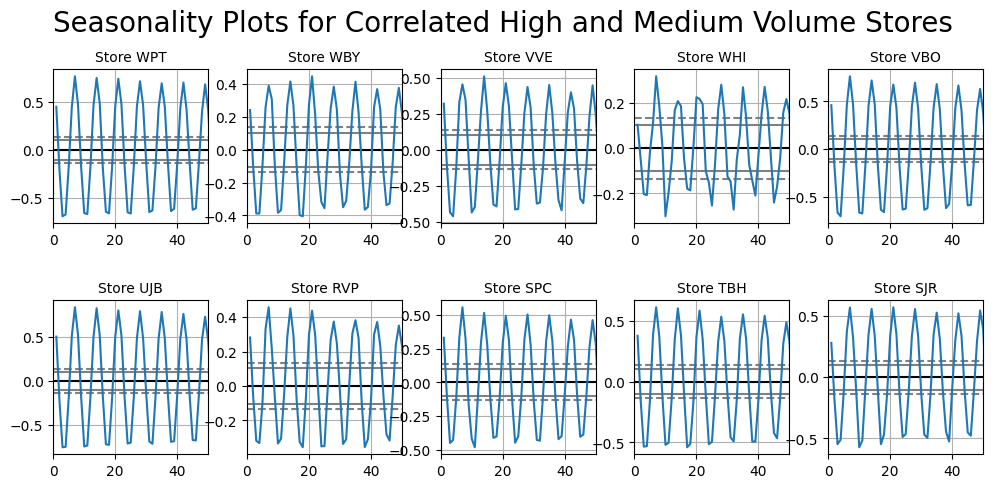

In [123]:
selected = ['WPT','WBY','VVE','WHI','VBO','UJB','RVP','SPC','TBH','SJR']

row = 0
col = 0
fig, axes = plt.subplots(figsize=(12, 5), nrows=2, ncols=5)
fig.suptitle('Seasonality Plots for Correlated High and Medium Volume Stores', fontsize=20, position=(0.5, 1.0))
for name in selected:
    sub = pd.plotting.autocorrelation_plot(dailyCustomers[name], axes[row, col])
    sub.set_xlim([0,50])
    sub.set_title('Store ' + name, fontsize=10)
    sub.xaxis.label.set_visible(False)
    sub.yaxis.label.set_visible(False)
    col += 1
    if col == 5:
        row += 1
        col = 0
plt.subplots_adjust(wspace=0.25, hspace=0.5)
plt.show()

###Seasonality Check for Low Volume Store###

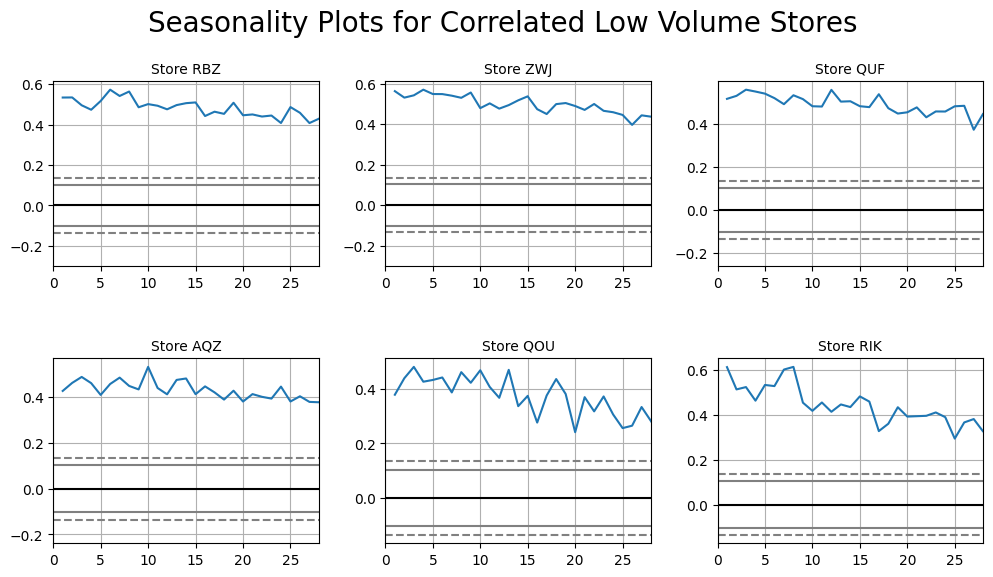

In [124]:
selected = ['RBZ','ZWJ','QUF','AQZ','QOU','RIK']

row = 0
col = 0
fig, axes = plt.subplots(figsize=(12, 6), nrows=2, ncols=3)
fig.suptitle('Seasonality Plots for Correlated Low Volume Stores', fontsize=20, position=(0.5, 1.0))
for name in selected:
    sub = pd.plotting.autocorrelation_plot(dailyCustomers[name], axes[row, col])
    sub.set_xlim([0,28])
    sub.set_title('Store ' + name, fontsize=10)
    sub.xaxis.label.set_visible(False)
    sub.yaxis.label.set_visible(False)
    col += 1
    if col == 3:
        row += 1
        col = 0
plt.subplots_adjust(wspace=0.25, hspace=0.5)
plt.show()

##Summary Dataframe##

In [125]:
summary_df = pd.concat([dailyCustomers.sum(axis=0).T, storeMarketing, storeOverheads, storeSize, storeStaff], axis=1)

In [126]:
summary_df.columns = summary_df.columns.astype(str)
summary_df.columns = summary_df.columns.str.replace('0', 'Total Customers')
summary_df.columns.values

array(['Total Customers', 'Marketing (£)', 'Overheads (£)', 'Size (msq)',
       'Staff'], dtype=object)

In [127]:
summary_df.head(10)

,Total Customers,Marketing (£),Overheads (£),Size (msq),Staff
WPT,360102,34000,87000,6656,30
WBY,340779,31000,24000,7380,45
VVE,332117,32000,14000,2536,21
WHI,318767,36000,32000,2035,10
UPM,179152,22000,13000,1259,8
TVW,172209,16000,73000,1117,6
VBO,169775,17000,63000,1713,12
UJB,150771,16000,84000,2218,21
RVP,141815,12000,98000,2687,24
SPC,140347,13000,39000,2332,13


###Correlation Heatmap for Store Attributes###

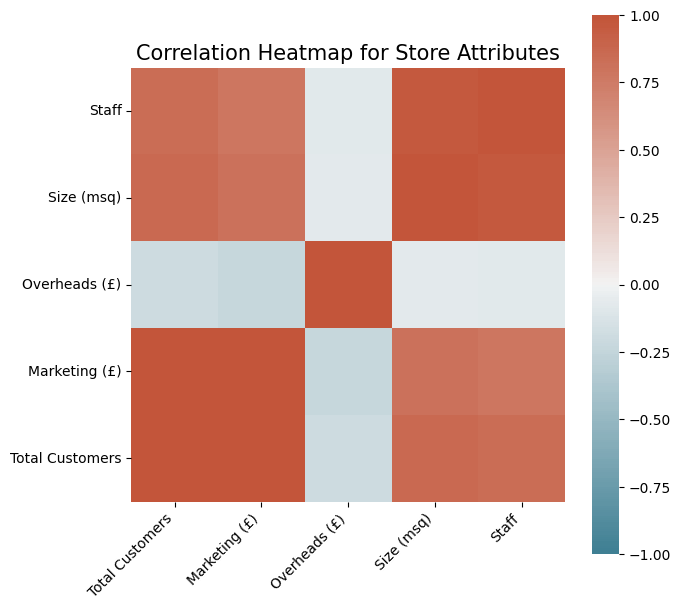

In [128]:
# adapted from https://towardsdatascience.com/better-heatmaps-and-correlation-matrix-plots-in-python-41445d0f2bec
#
# seaborn heatmap doesn't work correctly with matplotlib 3.1.1 (cuts the edges of the square off)
#  see https://github.com/mwaskom/seaborn/issues/1773
#
# need an older (or newer) version of matplotlib so close down PyCharm and run
#  pip install matplotlib==3.1.0 --force-reinstall

plt.figure(figsize=(7, 7))
corr = summary_df.corr()
ax = sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap=sns.diverging_palette(220, 20, n=200), square=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.invert_yaxis()
plt.title('Correlation Heatmap for Store Attributes',fontsize=15)
plt.show()


###Correlation Scatter subplots for Store Attributes

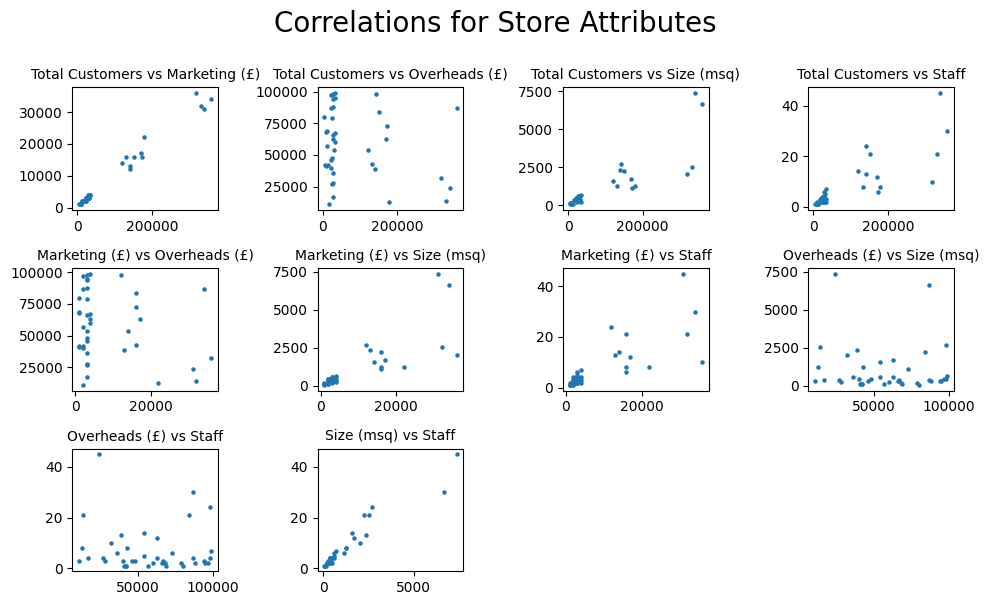

In [129]:
selected = summary_df.columns

counter = 1
fig = plt.figure(figsize=(10, 6))
fig.suptitle('Correlations for Store Attributes', fontsize=20, position=(0.5, 1.0))
for i, name_i in enumerate(selected):
    for j in range(i + 1, len(selected)):
        name_j = selected[j]
        sub = fig.add_subplot(3, 4, counter)
        sub.set_title(name_i + ' vs ' + name_j, fontsize=10)
        sub.scatter(summary_df[name_i], summary_df[name_j], s=5)
        counter += 1
plt.subplots_adjust(wspace=20, hspace=5)
plt.tight_layout()
plt.show()


###Attributes barcharts against 40 Stores###

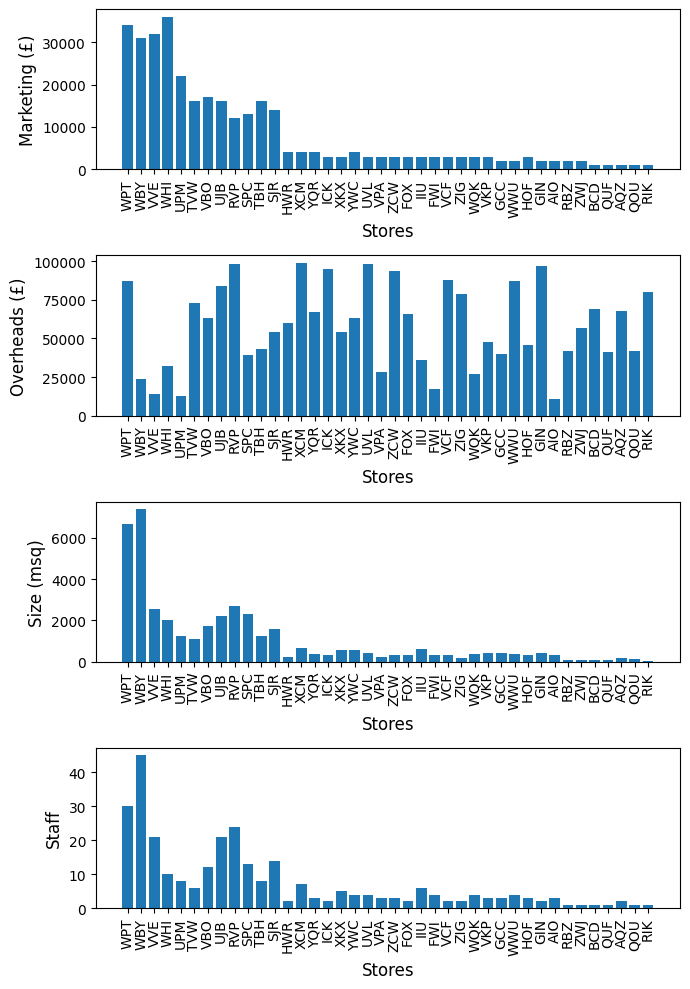

In [130]:
selected = list(summary_df.columns.values)
selected.remove('Total Customers')
#selected.remove('Overheads (£)')

plt.figure(figsize=(7, 10))
counter = 1
x_pos = np.arange(len(summary_df.index))
for attribute in selected:
    sub = plt.subplot(4,1, counter)
    sub.bar(x_pos, summary_df[attribute], align='center')
    sub.set_xticks([])
    sub.set_xticks(x_pos)
    sub.set_xticklabels(summary_df.index, rotation=90)
    sub.set_xlabel('Stores', fontsize=12)
    sub.set_ylabel(attribute, fontsize=12)
    counter += 1
plt.tight_layout()
plt.show()



###All Store Attributes Radar Subplots for High and Medium vs Low Volume Stores###

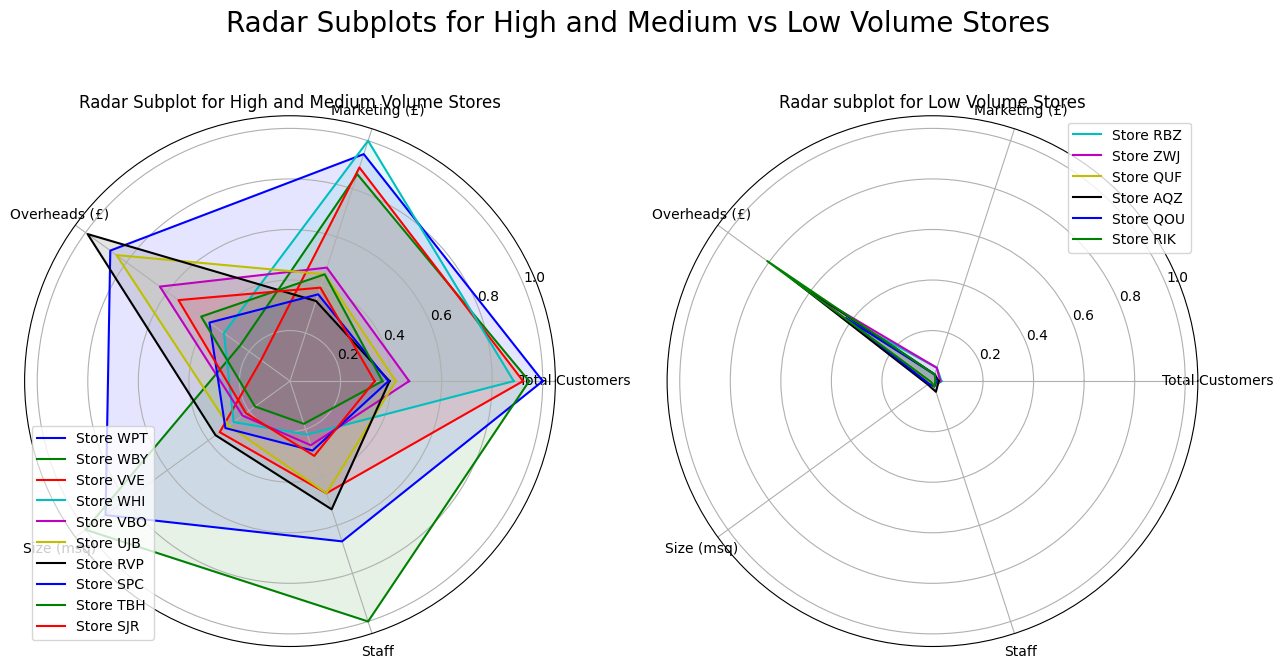

In [131]:
# Normalize data
normalised_data = summary_df / summary_df.max()

# Selected products for two overlaid radar subplots
selected_1 = ['WPT','WBY','VVE','WHI','VBO','UJB','RVP','SPC','TBH','SJR']
selected_2 = ['RBZ','ZWJ','QUF','AQZ','QOU','RIK']

# Radar chart setup
n_attributes = len(normalised_data.columns)
angles = [n / float(n_attributes) * 2 * np.pi for n in range(n_attributes + 1)]
colours = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
c = 0

# Create two radar charts in one window
fig, axes = plt.subplots(1, 2, figsize=(13, 7), subplot_kw={'projection': 'polar'})
fig.suptitle('Radar Subplots for High and Medium vs Low Volume Stores', fontsize=20, position=(0.5, 1.0))

# First Radar Chart (Left)
for name in selected_1:
    values = normalised_data.loc[[name]].values.flatten().tolist()
    values += values[:1]
    axes[0].plot(angles, values, colours[c % len(colours)], label='Store ' + name)
    axes[0].fill(angles, values, colours[c % len(colours)], alpha=0.1)
    c += 1

axes[0].set_ylim(ymax=1.05)
axes[0].set_xticks(angles[:-1])
axes[0].set_xticklabels(normalised_data.columns)
axes[0].set_title("Radar Subplot for High and Medium Volume Stores", fontsize=12)
axes[0].legend(loc=3)

# Second Radar Chart (Right)
for name in selected_2:
    values = normalised_data.loc[[name]].values.flatten().tolist()
    values += values[:1]
    axes[1].plot(angles, values, colours[c % len(colours)], label='Store ' + name)
    axes[1].fill(angles, values, colours[c % len(colours)], alpha=0.1)
    c += 1

axes[1].set_ylim(ymax=1.05)
axes[1].set_xticks(angles[:-1])
axes[1].set_xticklabels(normalised_data.columns)
axes[1].set_title("Radar subplot for Low Volume Stores", fontsize=12)
axes[1].legend(loc=0)

# Show the figure
plt.tight_layout()
plt.show()
